In [ ]:
pip install ucimlrepo


In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features

# metadata
X['InvoiceDate'] = pd.to_datetime(X['InvoiceDate'])
print(f"Dữ liệu ban đầu có: {X.shape[0]} dòng.")
X.head()

Dữ liệu ban đầu có: 541909 dòng.


/tmp/ipython-input-4146719292.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['InvoiceDate'] = pd.to_datetime(X['InvoiceDate'])


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# 1. Xử lý CustomerID bị thiếu
print(f"Số dòng bị thiếu CustomerID: {X['CustomerID'].isnull().sum()}")
print(f"Total lines: {X.count()}")
# df = df.dropna(subset=['CustomerID'])
# print(f"Số dòng sau khi bỏ CustomerID thiếu: {df.shape[0]}")

Số dòng bị thiếu CustomerID: 135080
Total lines: Description    540455
Quantity       541909
InvoiceDate    541909
UnitPrice      541909
CustomerID     406829
Country        541909
dtype: int64


In [ ]:
print(f"Số dòng bị thiếu CustomerID: {X['CustomerID'].isnull().sum()}")
X = X.dropna(subset=['CustomerID'])
print(f"Số dòng sau khi bỏ CustomerID thiếu: {X.shape[0]}")

Số dòng bị thiếu CustomerID: 135080
Số dòng sau khi bỏ CustomerID thiếu: 406829


In [ ]:
X = X[X['Quantity'] > 0]
print(f"Số dòng sau khi bỏ giao dịch trả hàng: {X.shape[0]}")

Số dòng sau khi bỏ giao dịch trả hàng: 397924


In [ ]:
X = X[X['UnitPrice'] > 0]
print(f"Number of lines after removing invalid price: {X.shape[0]}")

Number of lines after removing invalid price: 397884


In [ ]:
X['TotalPrice'] = X['Quantity'] * X['UnitPrice']

In [ ]:
X.head()


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
snapshot_date = X['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot Date: {snapshot_date}")

# 2. Calculate RFM
rfm = X.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),


    Frequency=('InvoiceDate', 'nunique'),

    Monetary=('TotalPrice', 'sum')
).reset_index()

# Đổi tên cột
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("Bảng RFM thô đã được tạo:")
rfm.head()

Snapshot Date: 2011-12-10 12:50:00
Bảng RFM thô đã được tạo:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


Chỉ số Skewness:
Recency       1.246048
Frequency    12.281775
Monetary     19.324953
dtype: float64


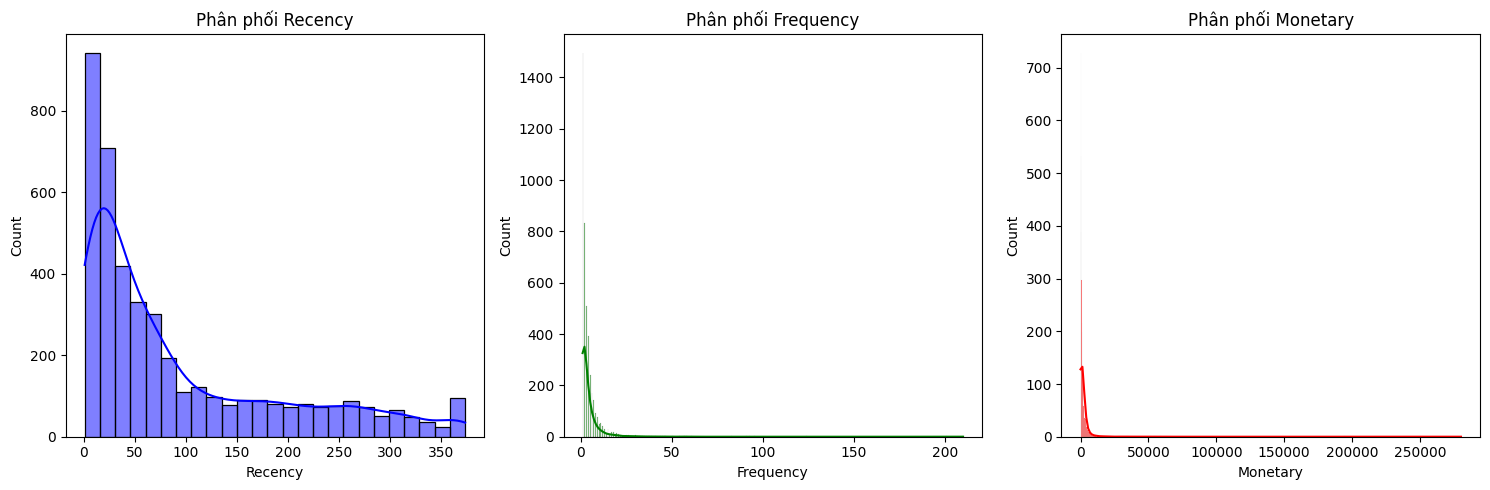

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Tính độ lệch cho cả 3 cột
skewness = rfm[['Recency', 'Frequency', 'Monetary']].skew()

print("Chỉ số Skewness:")
print(skewness)




fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Vẽ Recency
sns.histplot(rfm['Recency'], kde=True, ax=ax[0], color='blue')
ax[0].set_title('Phân phối Recency')

# Vẽ Frequency
sns.histplot(rfm['Frequency'], kde=True, ax=ax[1], color='green')
ax[1].set_title('Phân phối Frequency')

# Vẽ Monetary
sns.histplot(rfm['Monetary'], kde=True, ax=ax[2], color='red')
ax[2].set_title('Phân phối Monetary')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Tạo bảng rfm_log để chứa dữ liệu đã biến đổi
rfm_log = rfm.copy()

# Áp dụng Log Transform cho R, F, M
rfm_log['Recency'] = np.log(rfm_log['Recency'])
rfm_log['Frequency'] = np.log(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log(rfm_log['Monetary'])

print("Bảng RFM sau khi Log Transform:")
rfm_log.head()

Bảng RFM sau khi Log Transform:


,CustomerID,Recency,Frequency,Monetary
0,12346.0,5.786897,0.000000,11.253942
1,12347.0,0.693147,1.945910,8.368693
2,12348.0,4.317488,1.386294,7.494007
3,12349.0,2.944439,0.000000,7.471676
4,12350.0,5.736572,0.000000,5.812338


In [ ]:
# Khởi tạo Scaler
scaler = StandardScaler()

# Chỉ scale 3 cột R, F, M
rfm_scaled_data = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])

# Tạo DataFrame mới từ dữ liệu đã scale
# Giữ lại CustomerID để biết khách hàng là ai
rfm_scaled_df = pd.DataFrame(
    rfm_scaled_data,
    columns=['R_Scaled', 'F_Scaled', 'M_Scaled'],
    index=rfm_log['CustomerID'] # Giữ CustomerID làm chỉ mục (index)
).reset_index() # Chuyển CustomerID từ index thành cột

print("Bảng RFM cuối cùng (đã Log + Scale):")
rfm_scaled_df.head()

Bảng RFM cuối cùng (đã Log + Scale):


,CustomerID,R_Scaled,F_Scaled,M_Scaled
0,12346.0,1.409894,-1.049160,3.698719
1,12347.0,-2.146498,1.116099,1.410201
2,12348.0,0.383971,0.493402,0.716419
3,12349.0,-0.574674,-1.049160,0.698706
4,12350.0,1.374758,-1.049160,-0.617446


In [ ]:
# 1. Xuất file
rfm_scaled_df.to_csv('rfm_baseline_data.csv', index=False)
print("Đã lưu file 'rfm_baseline_data.csv' thành công.")

# 2. Rà soát chéo
print("\nKiểm tra thông số kỹ thuật của file cuối cùng:")
print(rfm_scaled_df[['R_Scaled', 'F_Scaled', 'M_Scaled']].describe())

Đã lưu file 'rfm_baseline_data.csv' thành công.

Kiểm tra thông số kỹ thuật của file cuối cùng:
           R_Scaled      F_Scaled      M_Scaled
count  4.338000e+03  4.338000e+03  4.338000e+03
mean  -1.048288e-16 -8.681135e-17 -7.010426e-16
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -2.630445e+00 -1.049160e+00 -4.179280e+00
25%   -6.124235e-01 -1.049160e+00 -6.841832e-01
50%    1.147066e-01 -2.778791e-01 -6.094235e-02
75%    8.296516e-01  7.416989e-01  6.542440e-01
max    1.505796e+00  4.900691e+00  4.721395e+00


In [ ]:
from google.colab import files
files.download('rfm_baseline_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>